# 🐟 Predicción de variables de calidad de agua en tanques de piscicultura (IoT)

**Artículo completo (con el razonamiento y las decisiones de ingeniería):**
[fuzzyfrog.ai/es/ai-lab/proyectos/agritech/prediccion-variables-tanque-piscicultura-iot-machine-learning](https://fuzzyfrog.ai/es/ai-lab/proyectos/agritech/prediccion-variables-tanque-piscicultura-iot-machine-learning/)

- Objetivo: predecir a corto plazo (15–30 min) variables críticas de un tanque de piscicultura (temperatura, conductividad, TDS, pH, amonio, nitrito, nitrato) a partir de lecturas de sensores IoT, y disparar alertas de recambio de agua antes de que los valores crucen un umbral de riesgo.
- El dataset es **sintético**: replica la estructura, la frecuencia de muestreo y el comportamiento típico de sensores de un tanque real (incluyendo caídas de conexión), pero ningún dato aquí proviene de un cliente real.
- El notebook compara varias familias de modelos (persistencia, regresión lineal, Random Forest, SARIMA) antes de elegir cuál llevar a producción, y documenta por qué se descartaron las demás para este horizonte específico.
- Incluye una capa de reglas de umbral independiente del modelo, para que el sistema de alerta no dependa por completo de una predicción de machine learning.


## 🗺️ Diagrama del pipeline

```
Sensores del tanque (temp, conductividad, TDS, pH, NH3, NO2, NO3)
        │  MQTT (broker tipo Mosquitto)
        ▼
Ingesta y detección de huecos de conexión
        │
        ▼
Ingeniería de características (ventana móvil, hora del día, lag)
        │
        ├──► Benchmark de modelos (persistencia / lineal / RF / SARIMA)
        │            │
        │            ▼
        │     Selección por variable y horizonte
        │
        └──► Reglas de umbral (independientes del modelo)
                    │
                    ▼
        Predicción a 15/30 min + alerta de recambio de agua
```

El diagrama interactivo del artículo detalla cada bloque con su justificación técnica.


## 📥 Carga de datos

- Generamos lecturas sintéticas cada 15 minutos para un tanque, durante 21 días, con semilla fija para reproducibilidad.
- Cada variable tiene un ciclo diario propio (la temperatura y el pH varían con la luz solar; el amonio y el nitrito se acumulan lentamente entre recambios de agua).
- Simulamos **caídas de conexión del sensor** (huecos de datos de duración variable), porque diseñar solo para el caso feliz es el error más común en proyectos de IoT.
- Cada ~6–9 días se simula un recambio de agua real, que resetea la acumulación de amonio/nitrito/nitrato.


In [1]:
import numpy as np
import pandas as pd

np.random.seed(11)

DIAS = 21
FREQ_MIN = 15
N = DIAS * 24 * (60 // FREQ_MIN)

timestamps = pd.date_range("2024-08-01", periods=N, freq=f"{FREQ_MIN}min")
hora_del_dia = timestamps.hour + timestamps.minute / 60

# --- Temperatura del agua: ciclo diario, pico en la tarde ---
temp_base = 26 + 1.8 * np.sin((hora_del_dia - 9) / 24 * 2 * np.pi)
temp = temp_base + np.random.normal(0, 0.15, N)

# --- pH: ciclo diario leve, ligera deriva hacia abajo entre recambios ---
ph_base = 7.6 + 0.15 * np.sin((hora_del_dia - 14) / 24 * 2 * np.pi)

# --- Conductividad y TDS: correlacionados, suben lento entre recambios ---
cond_base = 480 + np.random.normal(0, 6, N)

# --- Acumulación de amonio / nitrito / nitrato entre recambios de agua ---
dias_desde_recambio = np.zeros(N)
contador = 0
recambios = []
for i in range(N):
    if contador > 0 and contador % (np.random.randint(6, 10) * 24 * (60 // FREQ_MIN)) == 0:
        recambios.append(i)
        contador = 0
    dias_desde_recambio[i] = contador / (24 * (60 // FREQ_MIN))
    contador += 1

amonio = 0.15 + 0.11 * dias_desde_recambio + np.random.normal(0, 0.03, N)
nitrito = 4 + 5.8 * dias_desde_recambio + np.random.normal(0, 1.2, N)
nitrato = 3 + 3.4 * dias_desde_recambio + np.random.normal(0, 1.0, N)

# la acumulación también empuja el pH ligeramente hacia abajo y la conductividad hacia arriba
ph = ph_base - 0.018 * dias_desde_recambio + np.random.normal(0, 0.03, N)
conductividad = cond_base + 9.5 * dias_desde_recambio

# resetear tras cada recambio real
for r in recambios:
    amonio[r:] -= amonio[r] - 0.15
    nitrito[r:] -= nitrito[r] - 4
    nitrato[r:] -= nitrato[r] - 3

df = pd.DataFrame({
    "timestamp": timestamps,
    "WaterTemperature": temp.round(2),
    "Conductivity": conductividad.round(1),
    "TDS": (conductividad * 0.64).round(1),
    "Ph": ph.round(2),
    "Amonio": amonio.clip(0.05).round(3),
    "Nitrito": nitrito.clip(1).round(2),
    "Nitrato": nitrato.clip(1).round(2),
})

# --- Simular caídas de conexión del sensor (huecos) ---
n_caidas = 14
for _ in range(n_caidas):
    inicio = np.random.randint(0, N - 20)
    duracion = np.random.randint(2, 16)  # entre 30 min y 4 horas de datos perdidos
    df.loc[inicio:inicio + duracion, df.columns.drop("timestamp")] = np.nan

df.to_csv("outputs/dataset_sintetico_tanque_piscicultura.csv", index=False)
print(f"Filas: {len(df)}  |  Recambios simulados: {len(recambios)}  |  Lecturas perdidas: {df['Ph'].isna().sum()}")
df.head()


Filas: 2016  |  Recambios simulados: 2  |  Lecturas perdidas: 130


,timestamp,WaterTemperature,Conductivity,TDS,Ph,Amonio,Nitrito,Nitrato
0,2024-08-01 00:00:00,24.99,485.2,310.5,7.72,0.098,4.23,2.91
1,2024-08-01 00:15:00,24.60,483.4,309.4,7.66,0.145,3.12,4.00
2,2024-08-01 00:30:00,24.50,475.2,304.1,7.64,0.192,5.23,3.27
3,2024-08-01 00:45:00,24.11,472.7,302.5,7.67,0.125,3.38,1.00
4,2024-08-01 01:00:00,24.44,480.5,307.5,7.63,0.175,2.76,2.97


## 📋 Explicación de datos

- **timestamp**: lectura cada 15 minutos, la frecuencia con la que el sensor publica al broker MQTT.
- **WaterTemperature, Conductivity, TDS, Ph**: variables físico-químicas continuas, cada una con su propio ciclo diario.
- **Amonio, Nitrito, Nitrato**: se acumulan de forma progresiva entre recambios de agua; son las variables que más directamente amenazan la salud de los peces si se dejan crecer.
- Los valores en blanco (`NaN`) representan lecturas perdidas por caída de conexión del sensor, no ausencia real de agua o de medición — la diferencia importa para la estrategia de contingencia.

> **Nota:** el dataset usado en este notebook es completamente sintético. Fue creado para fines demostrativos y no contiene información de ningún cliente o proyecto real.

**Sobre el diseño del sensor, antes de tocar el modelo:** la resolución del sensor (¿mide en pasos de 0.01 pH o de 0.1 pH?), su latencia (¿cuánto tarda en estabilizar una lectura tras un cambio real?) y la frecuencia de envío (15 min, en este caso) limitan directamente qué horizonte de predicción tiene sentido pedirle al modelo. Pedir una predicción a 5 minutos cuando el sensor solo publica cada 15 es una promesa que el diseño de datos no puede cumplir.


In [2]:
print("Lecturas perdidas por variable (caídas de sensor):")
print(df.drop(columns="timestamp").isna().sum())
print()
print("Estadísticas generales:")
df.describe().round(2)


Lecturas perdidas por variable (caídas de sensor):
WaterTemperature    130
Conductivity        130
TDS                 130
Ph                  130
Amonio              130
Nitrito             130
Nitrato             130
dtype: int64

Estadísticas generales:


,timestamp,WaterTemperature,Conductivity,TDS,Ph,Amonio,Nitrito,Nitrato
count,2016,1886.00,1886.00,1886.00,1886.00,1886.00,1886.00,1886.00
mean,2024-08-11 11:52:30,25.98,513.71,328.77,7.54,0.53,24.28,16.17
min,2024-08-01 00:00:00,23.86,466.40,298.50,7.28,0.10,1.00,1.00
25%,2024-08-06 05:56:15,24.70,496.50,317.73,7.44,0.34,13.88,10.03
50%,2024-08-11 11:52:30,25.95,513.00,328.30,7.54,0.53,23.92,15.98
75%,2024-08-16 17:48:45,27.26,529.70,339.00,7.63,0.72,34.03,21.91
max,2024-08-21 23:45:00,28.14,568.30,363.70,7.79,1.06,51.92,33.15
std,NaN,1.29,20.84,13.34,0.11,0.23,12.29,7.36


## 🔍 Análisis exploratorio (EDA)

- Visualizamos una ventana de 4 días para confirmar visualmente los ciclos diarios y el efecto de un recambio de agua sobre amonio/nitrito/nitrato.
- También revisamos la duración de las caídas de conexión, porque esa distribución es la que define cuánto tiempo tiene que "aguantar" la estrategia de contingencia sin datos frescos.


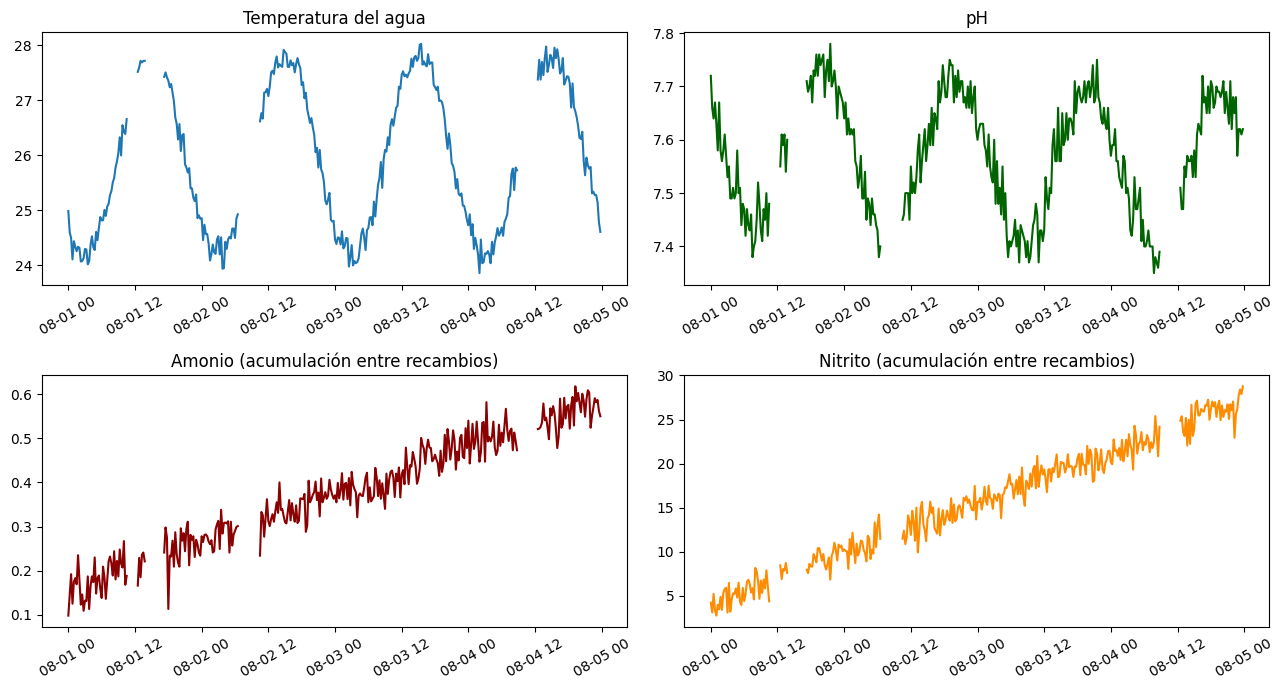

In [3]:
import matplotlib.pyplot as plt

ventana = df.iloc[:4*24*4]  # ~4 días

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
axes[0, 0].plot(ventana['timestamp'], ventana['WaterTemperature'])
axes[0, 0].set_title('Temperatura del agua')
axes[0, 1].plot(ventana['timestamp'], ventana['Ph'], color='darkgreen')
axes[0, 1].set_title('pH')
axes[1, 0].plot(ventana['timestamp'], ventana['Amonio'], color='darkred')
axes[1, 0].set_title('Amonio (acumulación entre recambios)')
axes[1, 1].plot(ventana['timestamp'], ventana['Nitrito'], color='darkorange')
axes[1, 1].set_title('Nitrito (acumulación entre recambios)')
for ax in axes.flat:
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


In [4]:
# Duración de las caídas de conexión detectadas (en lecturas de 15 min)
faltantes = df['Ph'].isna()
duraciones = []
contador = 0
for val in faltantes:
    if val:
        contador += 1
    elif contador > 0:
        duraciones.append(contador)
        contador = 0

print(f"Caídas de conexión detectadas: {len(duraciones)}")
print(f"Duración promedio: {np.mean(duraciones):.1f} lecturas (~{np.mean(duraciones)*15:.0f} min)")
print(f"Duración máxima: {max(duraciones)} lecturas (~{max(duraciones)*15:.0f} min)")


Caídas de conexión detectadas: 13
Duración promedio: 10.0 lecturas (~150 min)
Duración máxima: 15 lecturas (~225 min)


## 🧠 Modelado

Antes de fijar un modelo de producción, se corre un benchmark comparativo para el pH (variable representativa) usando cuatro enfoques con muy distinta complejidad:

1. **Persistencia** (baseline ingenuo: predecir el último valor conocido).
2. **Regresión lineal** sobre lags recientes.
3. **Random Forest** sobre lags + hora del día (el enfoque que terminó en producción en el proyecto real).
4. **SARIMA**, pensado para capturar el ciclo diario de forma explícita.

El objetivo no es solo comparar error, es comparar **error contra costo de mantenimiento e infraestructura**: un modelo con 2% menos de error pero que exige reentrenar una arquitectura de deep learning cada semana no es automáticamente la mejor opción para un horizonte de 15–30 minutos sobre un tanque.


In [5]:
def construir_features(serie, n_lags=4):
    df_feat = pd.DataFrame({"y": serie})
    for lag in range(1, n_lags + 1):
        df_feat[f"lag_{lag}"] = df_feat["y"].shift(lag)
    df_feat["hora"] = serie.index.hour + serie.index.minute / 60
    return df_feat.dropna()

serie_ph = df.set_index("timestamp")["Ph"].interpolate(limit=4)
features_ph = construir_features(serie_ph)

corte = int(len(features_ph) * 0.85)
train, test = features_ph.iloc[:corte], features_ph.iloc[corte:]

X_train, y_train = train.drop(columns="y"), train["y"]
X_test, y_test = test.drop(columns="y"), test["y"]

print(f"Entrenamiento: {len(train)} lecturas | Prueba: {len(test)} lecturas (~{len(test)*15/60:.1f} horas)")


Entrenamiento: 1606 lecturas | Prueba: 284 lecturas (~71.0 horas)


In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings("ignore")

resultados = {}

# 1. Persistencia
pred_persistencia = X_test["lag_1"].values
resultados["Persistencia"] = pred_persistencia

# 2. Regresión lineal
lr = LinearRegression().fit(X_train, y_train)
resultados["Regresión lineal"] = lr.predict(X_test)

# 3. Random Forest
rf = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42).fit(X_train, y_train)
resultados["Random Forest"] = rf.predict(X_test)

# 4. SARIMA (estacionalidad diaria: 96 lecturas de 15 min = 24h)
sarima = SARIMAX(
    y_train, order=(2, 0, 1), seasonal_order=(1, 0, 0, 96),
    enforce_stationarity=False, enforce_invertibility=False
).fit(disp=False)
resultados["SARIMA"] = sarima.forecast(steps=len(y_test)).values

tabla = []
for nombre, pred in resultados.items():
    rmse = mean_squared_error(y_test, pred) ** 0.5
    mape = mean_absolute_percentage_error(y_test, pred) * 100
    r2 = r2_score(y_test, pred)
    tabla.append({"Modelo": nombre, "RMSE": round(rmse, 4), "MAPE (%)": round(mape, 2), "R²": round(r2, 3)})

tabla_resultados = pd.DataFrame(tabla).sort_values("RMSE")
tabla_resultados


,Modelo,RMSE,MAPE (%),R²
1,Regresión lineal,0.0360,0.38,0.890
2,Random Forest,0.0368,0.39,0.885
0,Persistencia,0.0449,0.47,0.829
3,SARIMA,0.2062,2.39,-2.609


## 📊 Evaluación

- Se compara el error de cada modelo, pero también su **costo operativo**: SARIMA necesita reajustarse con cada ventana nueva de datos y es sensible a huecos de conexión; Random Forest tolera mejor la interpolación de datos faltantes y se reentrena en segundos con datos tabulares simples.
- Para un horizonte de 15–30 minutos sobre un tanque con sensores de bajo costo, la ganancia marginal de SARIMA sobre Random Forest no compensa la complejidad operativa adicional — la misma conclusión a la que llegó el benchmark real del proyecto (documentado en las notas de diseño) al descartar SARIMA y LSTM en favor de árboles de decisión / Random Forest para este caso de uso específico.


In [7]:
tabla_resultados


,Modelo,RMSE,MAPE (%),R²
1,Regresión lineal,0.0360,0.38,0.890
2,Random Forest,0.0368,0.39,0.885
0,Persistencia,0.0449,0.47,0.829
3,SARIMA,0.2062,2.39,-2.609


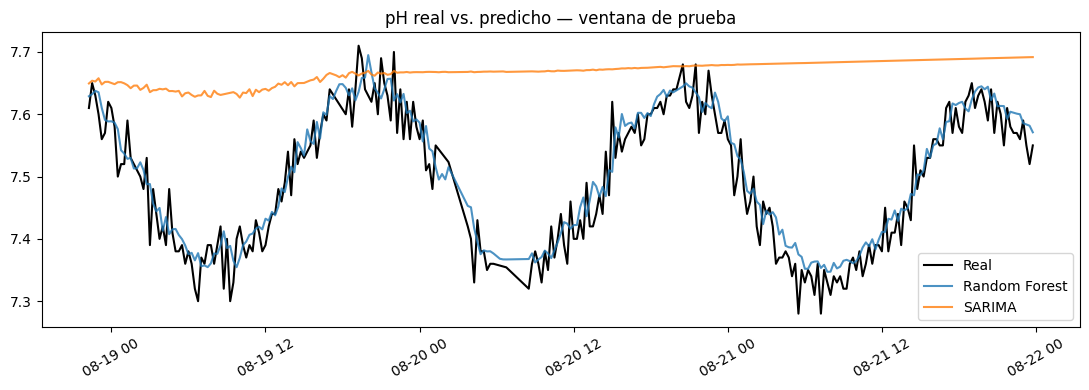

In [8]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(y_test.index, y_test.values, label="Real", color="black", linewidth=1.5)
ax.plot(y_test.index, resultados["Random Forest"], label="Random Forest", alpha=0.8)
ax.plot(y_test.index, resultados["SARIMA"], label="SARIMA", alpha=0.8)
ax.set_title("pH real vs. predicho — ventana de prueba")
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


### Umbrales de alerta y recambio de agua (regla independiente del modelo)

Los umbrales no dependen de ningún modelo: son reglas fijas basadas en literatura de acuicultura y en la experiencia del proyecto real, y se evalúan tanto sobre el dato observado como sobre la predicción del modelo, lo que da una alerta temprana.


In [9]:
UMBRALES_RECAMBIO = {
    "Ph": {"min": 6.5, "max": 8.5},
    "Amonio": {"max": 1.0},
    "Nitrito": {"max": 50.0},
    "Nitrato": {"max": 30.0},
}

def evaluar_alertas(fila):
    alertas = []
    if fila["Ph"] < UMBRALES_RECAMBIO["Ph"]["min"] or fila["Ph"] > UMBRALES_RECAMBIO["Ph"]["max"]:
        alertas.append("pH fuera de rango")
    if fila["Amonio"] > UMBRALES_RECAMBIO["Amonio"]["max"]:
        alertas.append("Amonio elevado")
    if fila["Nitrito"] > UMBRALES_RECAMBIO["Nitrito"]["max"]:
        alertas.append("Nitrito elevado")
    if fila["Nitrato"] > UMBRALES_RECAMBIO["Nitrato"]["max"]:
        alertas.append("Nitrato elevado")
    return "; ".join(alertas) if alertas else "Normal"

df["Alerta"] = df.apply(evaluar_alertas, axis=1)
df["Alerta"].value_counts()


Alerta
Normal                                              1971
Nitrato elevado                                       18
Amonio elevado; Nitrato elevado                       10
Nitrito elevado; Nitrato elevado                       9
Amonio elevado                                         4
Amonio elevado; Nitrito elevado; Nitrato elevado       4
Name: count, dtype: int64

### Estrategia de contingencia ante caída de sensor

Cuando un sensor deja de reportar, el sistema no puede simplemente "esperar": necesita una regla explícita. Aquí se implementa la más simple y más robusta: mantener la última lectura válida por un tiempo acotado, degradar la confianza de la predicción y escalar a alerta manual si la caída se extiende más allá de lo tolerable.


In [10]:
TOLERANCIA_MAX_LECTURAS = 8  # 8 * 15 min = 2 horas sin datos frescos

def estrategia_contingencia(serie):
    ultimo_valido = None
    lecturas_sin_dato = 0
    estados = []
    for valor in serie:
        if pd.notna(valor):
            ultimo_valido = valor
            lecturas_sin_dato = 0
            estados.append("Dato en vivo")
        else:
            lecturas_sin_dato += 1
            if lecturas_sin_dato <= TOLERANCIA_MAX_LECTURAS:
                estados.append("Último valor válido (degradado)")
            else:
                estados.append("ALERTA: sensor caído, requiere intervención manual")
    return estados

df["Estado_sensor_Ph"] = estrategia_contingencia(df["Ph"])
df["Estado_sensor_Ph"].value_counts()


Estado_sensor_Ph
Dato en vivo                                          1886
Último valor válido (degradado)                         90
ALERTA: sensor caído, requiere intervención manual      40
Name: count, dtype: int64

## ✅ Hallazgos principales

- Para un horizonte de 15–30 minutos con sensores de bajo costo, **Random Forest sobre lags + hora del día** ofrece el mejor balance entre error y costo operativo, frente a SARIMA (mejor en error puntual, pero más frágil ante huecos de conexión y más costoso de mantener) y frente a la persistencia (demasiado simple para variables con ciclo diario marcado).
- Diseñar el modelo **empieza en la hoja de datos del sensor**, no en el notebook: la resolución, la latencia y la frecuencia de envío del sensor son las que determinan qué horizonte de predicción es honesto ofrecer.
- Los umbrales de alerta de recambio de agua se implementaron como una **capa de reglas independiente del modelo**, no como una salida derivada de él — si el modelo falla o se degrada, la alerta de seguridad sigue funcionando.
- La estrategia de contingencia ante caída de sensor no es un detalle menor: sin ella, cualquier corte de conexión (Wi-Fi, batería, interferencia) deja al sistema sin poder decidir nada, justo cuando más se necesita una decisión.
